<a href="https://www.kaggle.com/code/mahdimashayekhi/mall-customers-segmentation?scriptVersionId=255637101" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Mall Customers Segmentation

## Importing libraries

In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', lambda x: '%.2f' % x)

## Loading the dataset

In [25]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/customer-segmentation-tutorial-in-python/Mall_Customers.csv


In [26]:
customers = pd.read_csv('/kaggle/input/customer-segmentation-tutorial-in-python/Mall_Customers.csv')
customers.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [27]:
df = customers.copy()
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Data Preprocessing

In [28]:
df.shape

(200, 5)

In [29]:
customers_id = df['CustomerID']
df.drop(['CustomerID', 'Gender'], axis=1, inplace=True)
customers_id

0        1
1        2
2        3
3        4
4        5
      ... 
195    196
196    197
197    198
198    199
199    200
Name: CustomerID, Length: 200, dtype: int64

In [30]:
df.rename(columns={'Annual Income (k$)' : 'Annual_Income', 'Spending Score (1-100)' : 'Spending_Score'}, inplace=True)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Age             200 non-null    int64
 1   Annual_Income   200 non-null    int64
 2   Spending_Score  200 non-null    int64
dtypes: int64(3)
memory usage: 4.8 KB


In [32]:
df.dtypes

Age               int64
Annual_Income     int64
Spending_Score    int64
dtype: object

In [33]:
df.describe()

,Age,Annual_Income,Spending_Score
count,200.00,200.00,200.00
mean,38.85,60.56,50.20
std,13.97,26.26,25.82
min,18.00,15.00,1.00
25%,28.75,41.50,34.75
50%,36.00,61.50,50.00
75%,49.00,78.00,73.00
max,70.00,137.00,99.00


In [34]:
df.isnull().sum()

Age               0
Annual_Income     0
Spending_Score    0
dtype: int64

In [35]:
df.duplicated().sum()

0

In [36]:
df['Income_Per_Score'] = df.Annual_Income / df.Spending_Score
df.drop(['Annual_Income', 'Spending_Score'], axis=1, inplace=True)

In [37]:
scaler = StandardScaler()
df = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

In [38]:
df.head()

,Age,Income_Per_Score
0,-1.42,-0.30
1,-1.28,-0.33
2,-1.35,-0.02
3,-1.14,-0.33
4,-0.56,-0.30


## Modeling and Evaluating

### 1. KMeans

In [39]:
inertia_values = []
k_values = range(2, 16)

for k in k_values:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init='auto', random_state=42)
    kmeans.fit(df)
    inertia_values.append(kmeans.inertia_)

In [40]:
inertia_series = pd.Series(inertia_values, index=k_values)
inertia_series

2    254.27
3     75.27
4     50.03
5     34.13
6     26.30
7     20.61
8     17.59
9     13.75
10    12.86
11    10.85
12     9.74
13     7.87
14     6.91
15     6.44
dtype: float64

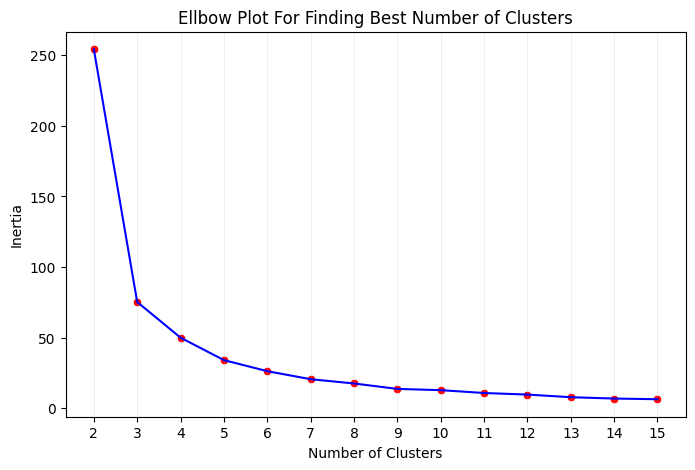

In [41]:
plt.figure(figsize=(8, 5))
sns.scatterplot(inertia_series, color='Red')
plt.plot(inertia_series, color='Blue')
plt.title('Ellbow Plot For Finding Best Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.xticks(range(2, 16))
plt.grid(axis='x', alpha=0.2)
plt.show()

In [42]:
# Kmeans with 3 cluster is the best according to the ellbow plot

In [43]:
kmeans3 = KMeans(n_clusters=3, init='k-means++', n_init='auto', random_state=42)
kmeans3.fit(df)

KMeans(n_clusters=3, n_init='auto', random_state=42)

In [44]:
kmeans3.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       0, 1, 2, 1, 2, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1,
       1, 1], dtype=int32)

In [45]:
Counter(kmeans3.labels_)

Counter({1: 122, 0: 76, 2: 2})

In [46]:
df.columns

Index(['Age', 'Income_Per_Score'], dtype='object')

In [47]:
kmeans3.cluster_centers_

array([[ 1.09009824, -0.02748101],
       [-0.67513631, -0.13681994],
       [-0.24041841,  9.39029507]])

In [48]:
cluster_centers = pd.DataFrame(kmeans3.cluster_centers_, columns=df.columns)
cluster_centers

,Age,Income_Per_Score
0,1.09,-0.03
1,-0.68,-0.14
2,-0.24,9.39


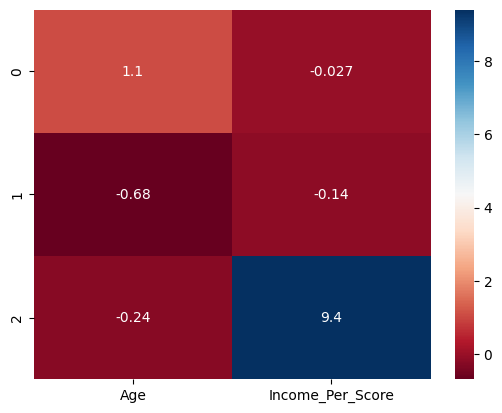

In [49]:
sns.heatmap(cluster_centers, cmap='RdBu', annot=True)
plt.show()

In [ ]:
# Cluster 0: Average people
# Cluster 1: Younger people 
# Cluster 2: Higher Salaries

In [50]:
score = round(silhouette_score(df, kmeans3.labels_, metric='euclidean', random_state=42) * 100, 3)
print(f"KMeans Score: {score}%")

KMeans Score: 58.122%


### 2. Hierarchical Clustering

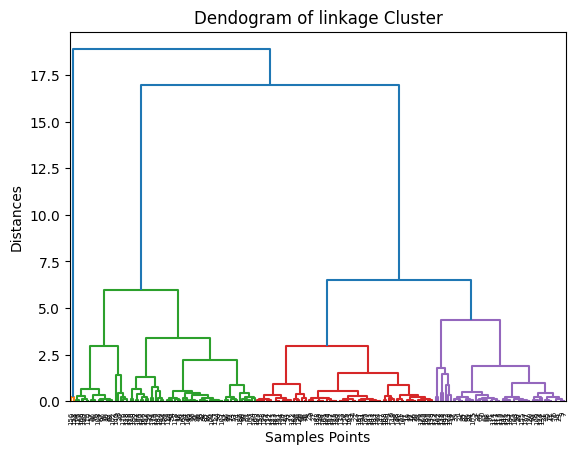

In [55]:
linkage_matrix = linkage(df, method='ward', metric='euclidean')
dendrogram_info = dendrogram(linkage_matrix, color_threshold=6)

plt.title('Dendogram of linkage Cluster')
plt.xlabel('Samples Points')
plt.ylabel('Distances')
plt.show()

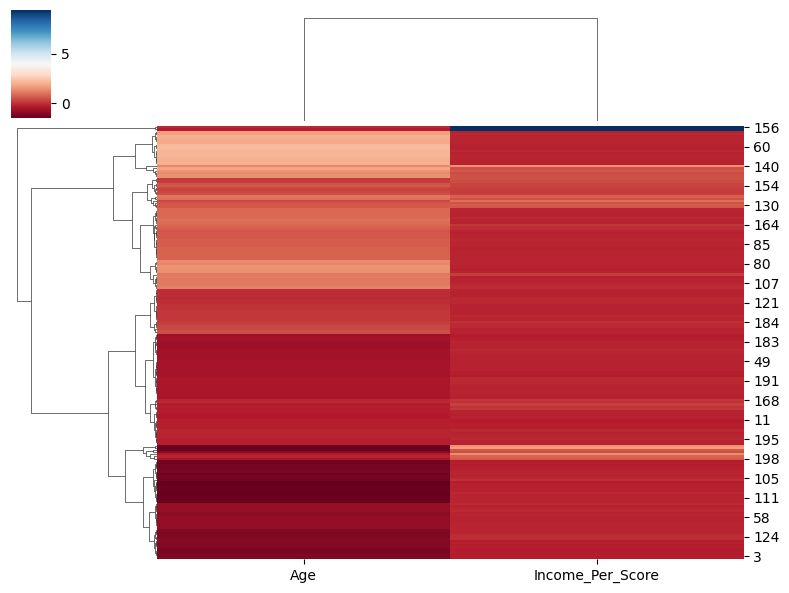

In [54]:
sns.clustermap(df, method='ward', metric='euclidean', figsize=(8, 6), cmap='RdBu')
plt.show()

In [ ]:
# Cluster 1: Middle age with high Income
# Cluster 2: Middle age with less income
# Cluster 3: Average age and income
# Cluster 4: Younger people

In [56]:
agg4 = AgglomerativeClustering(n_clusters=4, linkage='ward', metric='euclidean', )
agg4.fit(df)

AgglomerativeClustering(metric='euclidean', n_clusters=4)

In [58]:
agg4.labels_

array([2, 2, 2, 2, 1, 2, 1, 2, 0, 1, 0, 1, 0, 2, 1, 2, 1, 2, 0, 1, 1, 2,
       0, 1, 0, 1, 1, 1, 1, 2, 0, 2, 0, 2, 0, 2, 1, 1, 1, 2, 0, 2, 0, 1,
       0, 2, 0, 2, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 0, 2,
       1, 0, 2, 1, 0, 0, 0, 0, 0, 2, 1, 1, 2, 0, 0, 1, 0, 0, 2, 0, 0, 2,
       1, 0, 0, 2, 0, 1, 1, 2, 0, 2, 0, 2, 2, 0, 0, 2, 0, 2, 0, 0, 0, 0,
       0, 2, 1, 2, 2, 2, 0, 0, 0, 0, 2, 1, 1, 1, 2, 1, 1, 1, 0, 1, 0, 1,
       2, 1, 2, 1, 0, 1, 2, 1, 0, 1, 2, 1, 2, 2, 0, 1, 1, 1, 0, 1, 0, 1,
       0, 2, 3, 1, 3, 1, 0, 1, 2, 1, 0, 1, 0, 1, 1, 1, 0, 2, 2, 1, 0, 1,
       0, 2, 0, 1, 1, 1, 0, 1, 1, 1, 0, 2, 0, 1, 1, 1, 2, 1, 0, 1, 0, 1,
       2, 1])

In [59]:
Counter(agg4.labels_)

Counter({2: 53, 1: 72, 0: 73, 3: 2})

In [60]:
score = round(silhouette_score(df, agg4.labels_, metric='euclidean', random_state=42) * 100, 3)
print(f"Agglomerative Score: {score}%")

Agglomerative Score: 45.417%


### 3. DBSCAN

In [61]:
def tune_dbscan(data):

    results = []
    
    eps_values = np.arange(.1, 2.1, .1)
    min_samples_values = np.arange(2, 10, 1)
    
    for eps in eps_values:
        for min_samples in min_samples_values:
            dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
            dbscan.fit(data)
            labels = dbscan.labels_
    
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
            n_noise = list(labels).count(-1)
    
            if n_clusters > 1:
                score = silhouette_score(data, labels, metric='euclidean', sample_size=None)
            else:
                score = None
    
            results.append([eps, min_samples, n_clusters, n_noise, score])

    return results

In [62]:
columns = ['eps', 'min_samples', 'n_clusters', 'n_noise', 'silhouette_score']
results_df = pd.DataFrame(tune_dbscan(df), columns=columns)
results_df.head()

,eps,min_samples,n_clusters,n_noise,silhouette_score
0,0.10,2,12,28,0.23
1,0.10,3,8,36,0.21
2,0.10,4,6,48,0.31
3,0.10,5,6,48,0.31
4,0.10,6,4,58,0.30


In [63]:
(results_df.sort_values('silhouette_score', ascending=False)
           .groupby('silhouette_score')
           .head(1)).head()

,eps,min_samples,n_clusters,n_noise,silhouette_score
152,2.00,2,2,0,0.87
64,0.90,2,3,0,0.47
12,0.20,6,3,30,0.45
14,0.20,8,3,40,0.40
13,0.20,7,4,33,0.40


In [64]:
dbscan = DBSCAN(eps=2, min_samples=2)
dbscan.fit(df)

DBSCAN(eps=2, min_samples=2)

In [65]:
dbscan.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0])

In [66]:
Counter(dbscan.labels_)

Counter({0: 198, 1: 2})

In [67]:
score = round(silhouette_score(df, dbscan.labels_, metric='euclidean', random_state=42) * 100, 3)
print(f"DBSCAn Score: {score}%")

DBSCAn Score: 87.017%


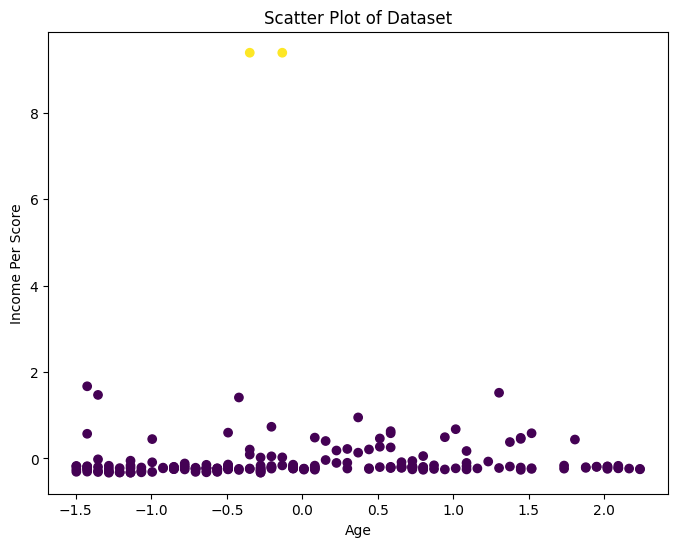

In [74]:
plt.figure(figsize=(8, 6))
plt.scatter(df['Age'], df['Income_Per_Score'], c=dbscan.labels_)
plt.title('Scatter Plot of Dataset')
plt.xlabel('Age')
plt.ylabel('Income Per Score')
plt.show()